In [ ]:
import requests
import pandas as pd
import numpy as np
import sqlite3 as sql
import matplotlib.pyplot as plt
import time

apiKey = "RGAPI-d54fbc39-37bf-4af8-b517-9903d66e77be"

#gets unique ID number for a player from their visable in-game name+tagline or summoner name
def get_puuid(summonerId=None, gameName = None, tagLine=None):
    if summonerId is not None:
        link = 'https://na1.api.riotgames.com/lol/summoner/v4/summoners/'
        response = requests.get(link + summonerId + "?api_key=" + apiKey)
        return response.json()['puuid']
    else:
        link = f'https://americas.api.riotgames.com/riot/account/v1/accounts/by-riot-id/{gameName}/{tagLine}?api_key={apiKey}'
        response = requests.get(link)
        return response.json()['puuid']

In [2]:
#gets the in-game name+tagline given a puuid
def get_idtag(puuid=None):
    link = 'https://americas.api.riotgames.com/riot/account/v1/accounts/by-puuid'
    response = requests.get(link + puuid + "?api_key=" + apiKey)
    id = {'gameName': response.json()['gameName'], 'tagLine': response.json()['tagLine']}
    return id

In [3]:
#Gets the lastest (default latest 20) games played by a player from their puuid
def get_match_history(puuid=None, start=0, matches=20):
    link = f'https://americas.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids?'
    params = f'start={start}&count={matches}'

    response = requests.get(link + params + '&api_key=' + apiKey)
    if response.status_code == 200:
        return response.json()
    else:
        print(f'Error getting match history for {puuid}') 
        return []

#Returns the json for a specific match from a matchId number from someone's match history
def get_match(matchId=None):
    link = f'https://americas.api.riotgames.com'
    param = f'/lol/match/v5/matches/{matchId}'

    response = requests.get(link + param + '?api_key=' + apiKey)
    return response.json()

In [4]:
#Gets the top players (base top 100 players max unless specified) in all of League of Legends. Top ranks are Master->Grandmaster->Challenger w/ Challenger being the top rank
def get_ladder(top=100):
    root = 'https://na1.api.riotgames.com'
    chall = '/lol/league/v4/challengerleagues/by-queue/RANKED_SOLO_5x5'
    gm = '/lol/league/v4/grandmasterleagues/by-queue/RANKED_SOLO_5x5'
    master = '/lol/league/v4/masterleagues/by-queue/RANKED_SOLO_5x5'

    chall_response = requests.get(root + chall + "?api_key=" + apiKey)
    gm_response = requests.get(root + gm + "?api_key=" + apiKey)
    master_response = requests.get(root + master + "?api_key=" + apiKey)

    if chall_response.status_code != 200 or gm_response.status_code != 200 or master_response.status_code != 200:
        print(f'Error: Ladder Status Codes: {chall_response.status_code}, {gm_response.status_code}, {master_response.status_code}')
        return pd.DataFrame()

    try:
        chall_df = pd.DataFrame(chall_response.json()['entries'])
        gm_df = pd.DataFrame(gm_response.json()['entries'])
        master_df = pd.DataFrame(master_response.json()['entries'])

        solo_queue_df = pd.concat([chall_df, gm_df, master_df]).reset_index(drop=True)
        solo_queue_df = solo_queue_df.sort_values(by='leaguePoints', ascending=False)
        solo_queue_df = solo_queue_df.head(top)
        solo_queue_df = solo_queue_df.drop(columns= ['rank', 'inactive', 'veteran', 'freshBlood'], errors='ignore')
        return solo_queue_df.reset_index(drop=True)
    
    except Exception as e:
        print(f'Json Error: {e}')
        return pd.DataFrame()

# Return a set of unique average ranked played from the last (default 20) matches played with a given puuid. 
# Note this gives up to 9 players per match not including the seed puuid. Less if people are partied together
def get_average_players(puuid=None, matches=20):
    seed_puuid = puuid
    if not seed_puuid:
        print('Error: seed_puuid is empty or None')
        return pd.DataFrame(columns=['puuid'])
    
    average_matches = get_match_history(puuid=puuid, matches=matches)
    if not average_matches:
        print('Error: get_match_history returned nothing for seed_puuid')
        return pd.DataFrame(columns=['puuid'])
    
    average_players = set()
    for matchId in average_matches:
        match_data = get_match(matchId=matchId)

        if not match_data  or 'info' not in match_data: 
            print('Error: get_match_history returned nothing for seed_puuid')
            continue

        for p in match_data['info']['participants']:
            player = p.get('puuid')
            if player and player != seed_puuid:
                average_players.add(player)
        time.sleep(1.2)
        
    average_player_df = pd.DataFrame(list(average_players), columns=['puuid'])
    print(f'Returning {len(average_players)} players.')
    return average_player_df

In [5]:
#Returns a unique list of matches from the top ranked players returned from get_ladder(). Gets the last (default 20) matches for each top ranked players before filtering out only unique matchIDs
def get_top_matches(ladder, matches=20):
    all_matches = set()

    for index, player in ladder.iterrows():
        player_puuid = player.get('puuid')
        if not player_puuid:
            continue

        print(f'Fetching match history for player {index + 1}...')
        player_matches = get_match_history(puuid=player_puuid, matches=matches)
        
        for match_id in player_matches:
            all_matches.add(match_id)
        time.sleep(1.2)

    unique_top_matches = list(all_matches)
    top_matches_df = pd.DataFrame(unique_top_matches, columns=['matchId'])
    return top_matches_df

#Returns a unique list of matches from from list of average ranked players from get_average_players to be processed later
# Note this gives up to (default 20) matches for every puuid in the puuids list
def get_average_matches(puuids, matches=20):
    all_matches = set()

    for index, player in puuids.iterrows():
        player_puuid = player.get('puuid')
        if not player_puuid: continue

        print(f'Fetching match history for player {index + 1}...')
        player_matches = get_match_history(puuid=player_puuid, matches=matches)

        for match_id in player_matches:
            all_matches.add(match_id)
        time.sleep(1.2)

    unique_average_matches = list(all_matches)
    average_matches_df = pd.DataFrame(unique_average_matches, columns=['matchId'])
    return average_matches_df

In [6]:
#Processes the data from a match into multiple dataframes for the match metadata, team-wide data, and the multitude of stats for all players for the database
def process_match(match_json):
    metadata = match_json['metadata']
    info = match_json['info']
    matchId = match_json['metadata']['matchId']

    raw_duration = info['gameDuration']
    minutes = int(raw_duration // 60)
    seconds = int(raw_duration % 60)
    readable_time = f"{minutes}:{seconds:02d}"

    match_df = pd.DataFrame([{
        #basic match metadata
        'match_id': matchId,
        'game_version': info['gameVersion'],
        'game_duration': readable_time,
        'queue_id': info['queueId'],
        'game_mode': info['gameMode']
    }])

    teams = match_json['info']['teams']
    team_records = []
    for team in teams:
        #team-wide data for each match, mainly objectives
        obj = team['objectives']
        ban_ids = ",".join([str(ban['championId']) for ban in team.get('bans', [])])

        first_objs = [obj['baron']['first'], obj['champion']['first'], obj['dragon']['first'], obj['horde']['first'], obj['inhibitor']['first'], obj['tower']['first']]
        first_control = sum(1 for first in first_objs if first)

        objectives_taken = obj['baron']['kills'] + obj['dragon']['kills'] + obj['horde']['kills'] + obj['inhibitor']['kills'] + obj['tower']['kills']
        macro_efficiency = objectives_taken / obj['champion']['kills'] if obj['champion']['kills'] > 0 else objectives_taken

        team_records.append({
            'match_id': matchId,
            'team_id': team['teamId'],
            'win': 1 if team['win'] else 0,
            'bans': ban_ids,

            'baron_kills': obj['baron']['kills'],
            'baron_first': 1 if obj['baron']['first'] else 0,
            
            'champion_kills': obj['champion']['kills'],
            'champion_first': 1 if obj['champion']['first'] else 0,

            'dragon_kills': obj['dragon']['kills'],
            'dragon_first': 1 if obj['dragon']['first'] else 0,

            'grubs_kills': obj['horde']['kills'],
            'grubs_first': 1 if obj['horde']['first'] else 0,

            'inhibitor_kills': obj['inhibitor']['kills'],
            'inhibitor_first': 1 if obj['inhibitor']['first'] else 0,

            'tower_kills': obj['tower']['kills'],
            'tower_first': 1 if obj['tower']['first'] else 0,

            'macro_efficiency': macro_efficiency,
            'first_control': first_control
        })

    team_df = pd.DataFrame(team_records)

    participants = match_json['info']['participants']
    players_list = []
    
    for player in participants:
        #common player data for each match
        player_data = {
            'match_id': matchId,
            'puuid': player['puuid'],
            'riotIdGameName': player['riotIdGameName'],
            'riotIdTagline': player['riotIdTagline'],
            'team_id': player['teamId'],
            'win': 1 if player['win'] else 0,
            'gameEndedInEarlySurrender': 1 if player['gameEndedInEarlySurrender'] else 0,
            'gameEndedInSurrender': 1 if player['gameEndedInSurrender'] else 0,

            'championId': player['championId'],
            'championName': player['championName'],
            'teamPosition': player['teamPosition'],

            'kills': player['kills'],
            'deaths': player['deaths'],
            'assists': player['assists'],
            'summOne': player['summoner1Id'],
            'summTwo': player['summoner2Id'],
            'totalMinionsKilled': player['totalMinionsKilled'],

            'largestKillingSpree': player['largestKillingSpree'],
            'longestTimeSpentLiving': player['longestTimeSpentLiving'],
            'totalTimeSpentDead': player['totalTimeSpentDead'],

            'goldEarned': player['goldEarned'],
            'goldSpent': player['goldSpent'],

            'item0': player['item0'],
            'item1': player['item1'],
            'item2': player['item2'],
            'item3': player['item3'],
            'item4': player['item4'],
            'item5': player['item5'],
            'item6': player['item6'],

            'firstBloodKill': 1 if player['firstBloodKill'] else 0,
            'firstBloodAssist': 1 if player['firstBloodAssist'] else 0,
            'firstTowerKill': 1 if player['firstTowerKill'] else 0,
            'firstTowerAssist': 1 if player['firstTowerAssist'] else 0,
            'turretTakedowns': player['turretTakedowns'],
            'dragonKills': player['dragonKills'],

            'damageDealtToBuildings': player['damageDealtToBuildings'],
            'damageDealtToObjectives': player['damageDealtToObjectives'],
            'damageDealtToTurrets': player['damageDealtToTurrets'],

            'totalDamageDealtToChampions': player['totalDamageDealtToChampions'],
            'totalDamageTaken': player['totalDamageTaken'],
            'totalDamageShieldedOnTeammates': player['totalDamageShieldedOnTeammates'],
            'totalHeal': player['totalHeal'],
            'totalHealsOnTeammates': player['totalHealsOnTeammates'],
            'totalDamageTaken': player['totalDamageTaken'],
            'totalTimeCCDealt': player['totalTimeCCDealt'],

            'totalAllyJungleMinionsKilled': player['totalAllyJungleMinionsKilled'],
            'totalEnemyJungleMinionsKilled': player['totalEnemyJungleMinionsKilled'],

            'visionScore': player['visionScore'],
            'wardsPlaced': player['wardsPlaced'],
            'wardsKilled': player['wardsKilled'],
            'visionWardsBoughtInGame': player['visionWardsBoughtInGame'],
        }
        #extra unique challenges that may see more specific correlation with winning, using get() here as some challenges might not exist in some gamemodes and might error otherwise
        target_challenges = ['goldPerMinute', 'bountyGold', 'killParticipation', 'turretPlatesTaken', 'dragonTakedowns', 'soloKills', 'takedownsFirstXMinutes', 'takedownsFirst25Minutes', 
                             'damagePerMinute', 'earlyLaningPhaseGoldExpAdvantage', 'laneMinionsFirst10Minutes', 'laningPhaseGoldExpAdvantage', 'maxCsAdvantageOnLaneOpponent', 
                             'maxLevelLeadLaneOpponent', 'killsOnOtherLanesEarlyJungleAsLaner', 'fastestLegendary', 'enemyChampionImmobilizations', 'maxKillDeficit', 'outnumberedKills', 
                            'pickKillWithAlly', 'saveAllyFromDeath', 'soloTurretsLategame', 'junglerKillsEarlyJungle', 'killsOnLanersEarlyJungleAsJungler', 'scuttleCrabKills', 
                            'jungleCsBefore10Minutes', 'enemyJungleMonsterKills', 'junglerTakedownsNearDamagedEpicMonster', 'visionScoreAdvantageLaneOpponent', 'visionScorePerMinute', 
                            'controlWardsPlaced', 'controlWardTimeCoverageInRiverOrEnemyHalf']
        challenges = player.get('challenges', {})
        for key in target_challenges:
            player_data[key] = challenges.get(key, 0)

        players_list.append(player_data)

    players_df = pd.DataFrame(players_list)

    return match_df, team_df, players_df

In [7]:
#Returns a json of the entire match timeline for a given match id
def get_match_timeline_json(matchId):
    link = f'https://americas.api.riotgames.com/lol/match/v5/matches/{matchId}/timeline'
    response = requests.get(link + '?api_key=' + apiKey)
    return response.json()

#Returns players stats from a match timeline at the given timestamp
def extract_timeline_stats(timeline_json, timestamp=15):
    timeframe = timeline_json['info']['frames'][timestamp]
    player_data = timeframe['participantFrames']

    stats_at_time = []
    for playerId, data in player_data.items():
        stats_at_time.append({'participantId': playerId, 'totalGold': data['totalGold'], 'level': data['level'], 'minionsKilled': data['minionsKilled'] + data['jungleMinionsKilled']})

    return stats_at_time

#Adds columns for gold, xp, minions killed, and gold difference vs lane opponent to player data frames at given timestamps. Can insert multiple timestamps at once
def process_match_with_timeline(match_json, timeline_json, timestamps = [5, 10, 15, 20]):
    match_df, team_df, players_df = process_match(match_json)

    for minute in timestamps:
        if len(timeline_json['info']['frames']) <= minute:
            continue

        stats_list = extract_timeline_stats(timeline_json, minute)
        snapshot_at_tf = {}

        for participant in stats_list:
            playerId = int(participant['participantId'])
            snapshot_at_tf[playerId] = participant

        gold_ts, xp_ts, minions_ts, gold_diff_ts = [], [], [], []

        for i in range(1, 11):
            player_stats = snapshot_at_tf.get(i, {'totalGold': 0, 'level': 0, 'minionsKilled': 0})

            opponent_id = i + 5 if i <= 5 else i - 5
            opponent_stats = snapshot_at_tf.get(opponent_id,{'totalGold': 0, 'level': 0, 'minionsKilled': 0})

            gold_ts.append(player_stats['totalGold'])
            xp_ts.append(player_stats['level'])
            minions_ts.append(player_stats['minionsKilled'])
            gold_diff_ts.append(player_stats['totalGold'] - opponent_stats['totalGold'])

        players_df[f'goldAt{minute}'] = gold_ts
        players_df[f'levelAt{minute}'] = xp_ts
        players_df[f'minionsAt{minute}'] = minions_ts
        players_df[f'goldDiffAt{minute}'] = gold_diff_ts

    return match_df, team_df, players_df

In [8]:
#Checks if a match id has already been processed to avoid duplicates. Makes sure the database exists first
def is_match_processed(matchId, conn):
    cursor = conn.cursor()
    try:
        cursor.execute(f"SELECT 1 FROM matches WHERE match_id = '{matchId}'")
        return cursor.fetchone() is not None
    except sql.OperationalError:
        return False

#Saves the dataframes returned by process_match() to the database
def save_to_db(match_df, team_df, players_df, db_path='league_data.db'):
    conn = sql.connect(db_path)

    try: 
        match_df.to_sql('matches', conn, if_exists='append', index=False)
        team_df.to_sql('teams', conn, if_exists='append', index=False)
        players_df.to_sql('participants', conn, if_exists='append', index=False)
        conn.commit()
        # print(f"Saved match: {match_df['match_id'].iloc[0]}")

    except Exception as e:

        actual_error = e.__cause__ if e.__cause__ else e
        print(f"Database Error: {actual_error}")
        conn.rollback()

    finally: conn.close()

In [9]:
#Start of main function, clears db if it exists, output of ladder shows the top players of the solo queue ladder including their puuids, wins/losses, ranked league points (LP), and if they're on a winstreak
conn = sql.connect('league_data.db')
reset = 'matches', 'teams', 'participants'
for table in reset:
    try:
        conn.execute(f'DROP TABLE IF EXISTS {table}')
    except Exception as e:
        continue

ladder_df = get_ladder(top=100)
ladder_df

,puuid,leaguePoints,wins,losses,hotStreak
0,44dBsY50V05YIQZUP_TFyWu16H_s9HSUNfxCQA4qmxC4Fu...,1094,170,80,False
1,AJjsIjqSxucdYr_LjdfHDmSS4US51CdsD3E9tHz42C-jL6...,1030,123,39,False
2,Ay8ueax2rmysh-dPL6U45uIaQG8ZMGtHxHnHL79df0tiVd...,1000,165,113,False
3,t_sFS_L_ey7IwF2jHg790VcRFXkmPCOBzJQP9nEJP4c50u...,960,257,125,False
4,YlXeQPKyd2CLhsMOGCfh2tNnBVkh_Y6Pm5tVvvmrk7JuHX...,955,148,92,True
...,...,...,...,...,...
95,NGOBscJI5DkK_UYdBvisQ3fgg4wNIQeERvvbnXJSKvG1xz...,553,284,192,False
96,0046MDYXooGYetfJpaw6KWRDx3r03rFfCMPAbYWevjRjVR...,550,253,226,False
97,R9uaPlloHf25Et4Z9464OG7E25tl_t-6jqIOaTE2lYHyVk...,548,142,56,False
98,Ll3zcmo36N0rXbUxnVwN6INXu9LqTzFycOKaHeauzafbl7...,547,475,418,False


In [10]:
#Fetch match history of match ids for COUNT games for every top player
top_match_ids = get_top_matches(ladder_df, matches=10)
display(top_match_ids)

Fetching match history for player 1...
Fetching match history for player 2...
Fetching match history for player 3...
Fetching match history for player 4...
Fetching match history for player 5...
Fetching match history for player 6...
Fetching match history for player 7...
Fetching match history for player 8...
Fetching match history for player 9...
Fetching match history for player 10...
Fetching match history for player 11...
Fetching match history for player 12...
Fetching match history for player 13...
Fetching match history for player 14...
Fetching match history for player 15...
Fetching match history for player 16...
Fetching match history for player 17...
Fetching match history for player 18...
Fetching match history for player 19...
Fetching match history for player 20...
Fetching match history for player 21...
Fetching match history for player 22...
Fetching match history for player 23...
Fetching match history for player 24...
Fetching match history for player 25...
Fetching 

,matchId
0,NA1_5552916883
1,NA1_5553531663
2,NA1_5553503208
3,NA1_5553104350
4,NA1_5552922904
...,...
711,NA1_5553003465
712,NA1_5553016159
713,NA1_5552547688
714,NA1_5552727050


In [11]:
#Processes matches and saves them to league_data.db. Displays The 3 tables matches, teams, participants at the end
#Running with process_match_with_timeline over process_match to get data throughout the game instead of end-of-game only stats
intervals = [5, 10, 15, 20, 25]

for index, match_id in top_match_ids['matchId'].items():
    if is_match_processed(match_id, conn):
        continue

    try:
        match_data = get_match(match_id)
        participants = match_data['info']['participants']
        early_ff = any(participant.get('gameEndedInEarlySurrender', False) for participant in participants)

        if match_data['info']['gameMode'] != "CLASSIC" or early_ff:
            continue

        timeline_data = get_match_timeline_json(match_id)

        match_df, team_df, players_df = process_match_with_timeline(match_data, timeline_data, timestamps=intervals)
        match_df['rank_group'] = 'Top'
        team_df['rank_group'] = 'Top'
        players_df['rank_group'] = 'Top'

        save_to_db(match_df, team_df, players_df)
        print(f"Successfully saved match {index + 1} data to database")
        time.sleep(2.4)

    except Exception as e:
        print(f"Error processing match {match_id}: {e}")

print("Successfully saved all match data to database")

df_matches = pd.read_sql("SELECT * FROM matches", conn)
df_teams = pd.read_sql("SELECT * FROM teams", conn)
df_participants = pd.read_sql("SELECT * FROM participants", conn)

display(df_matches, df_teams, df_participants)

Successfully saved match 1 data to database
Successfully saved match 3 data to database
Successfully saved match 6 data to database
Successfully saved match 7 data to database
Successfully saved match 8 data to database
Successfully saved match 9 data to database
Successfully saved match 10 data to database
Successfully saved match 11 data to database
Successfully saved match 12 data to database
Successfully saved match 13 data to database
Successfully saved match 14 data to database
Successfully saved match 15 data to database
Successfully saved match 16 data to database
Successfully saved match 17 data to database
Successfully saved match 18 data to database
Successfully saved match 19 data to database
Successfully saved match 20 data to database
Successfully saved match 21 data to database
Successfully saved match 22 data to database
Successfully saved match 23 data to database
Successfully saved match 24 data to database
Successfully saved match 25 data to database
Successfully sav

,match_id,game_version,game_duration,queue_id,game_mode,rank_group
0,NA1_5552916883,16.9.772.1032,26:19,420,CLASSIC,Top
1,NA1_5553503208,16.9.772.1032,32:13,420,CLASSIC,Top
2,NA1_5553359411,16.9.772.1032,24:40,420,CLASSIC,Top
3,NA1_5552566195,16.9.772.1032,27:41,420,CLASSIC,Top
4,NA1_5552649872,16.9.772.1032,34:32,420,CLASSIC,Top
...,...,...,...,...,...,...
658,NA1_5552030636,16.9.772.1032,30:12,420,CLASSIC,Top
659,NA1_5553003465,16.9.772.1032,33:13,420,CLASSIC,Top
660,NA1_5553016159,16.9.772.1032,27:37,420,CLASSIC,Top
661,NA1_5552547688,16.9.772.1032,26:57,420,CLASSIC,Top


,match_id,team_id,win,bans,baron_kills,baron_first,champion_kills,champion_first,dragon_kills,dragon_first,grubs_kills,grubs_first,inhibitor_kills,inhibitor_first,tower_kills,tower_first,macro_efficiency,first_control,rank_group
0,NA1_5552916883,100,0,"104,800,119,950,114",0,0,18,0,0,0,0,0,0,0,2,0,0.111111,0,Top
1,NA1_5552916883,200,1,"35,517,119,34,111",1,1,38,1,3,1,3,1,1,1,7,1,0.394737,6,Top
2,NA1_5553503208,100,0,"24,81,84,800,799",0,0,35,0,1,1,0,0,0,0,3,1,0.114286,2,Top
3,NA1_5553503208,200,1,"203,-1,-1,777,92",1,1,42,1,3,0,3,1,1,1,8,0,0.380952,4,Top
4,NA1_5553359411,100,0,"134,887,119,59,555",0,0,15,0,0,0,0,0,0,0,1,0,0.066667,0,Top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321,NA1_5553016159,200,0,"22,54,147,11,517",0,0,21,1,0,0,0,0,0,0,2,1,0.095238,2,Top
1322,NA1_5552547688,100,0,"157,58,555,78,29",0,0,18,1,0,0,0,0,0,0,3,0,0.166667,1,Top
1323,NA1_5552547688,200,1,"64,119,3,517,143",1,1,29,0,4,1,3,1,2,1,9,1,0.655172,5,Top
1324,NA1_5552727050,100,1,"17,134,104,119,29",0,0,16,1,0,0,3,1,0,0,3,1,0.375000,3,Top


,match_id,puuid,riotIdGameName,riotIdTagline,team_id,win,gameEndedInEarlySurrender,gameEndedInSurrender,championId,championName,...,goldDiffAt15,goldAt20,levelAt20,minionsAt20,goldDiffAt20,goldAt25,levelAt25,minionsAt25,goldDiffAt25,rank_group
0,NA1_5552916883,GNvxxUD1VUWnImY1ZHisXIv4uScZTNuVEWsjl7gk864owm...,Summoner V,NA2,100,0,0,0,420,Illaoi,...,611.0,8557.0,14.0,193.0,1004.0,12942.0,17.0,221.0,2345.0,Top
1,NA1_5552916883,DqVbbJ4LKWVA14nVA0UE4Bgy6JTbvUP2tgh0ihXYHKiLMm...,batChest LEAGUE,NA1,100,0,0,0,9,FiddleSticks,...,-2086.0,6382.0,10.0,105.0,-5932.0,7768.0,12.0,129.0,-8411.0,Top
2,NA1_5552916883,IJux05vtAp2KsRRbm7MluLmQx0kAKfrqd4W3n056rdy7B-...,HighItsAdam,NA1,100,0,0,0,101,Xerath,...,389.0,7844.0,12.0,164.0,1193.0,9467.0,13.0,186.0,615.0,Top
3,NA1_5552916883,gWDE4SnBLyxtReLD9G6lj55yuEnOhVaFjk4Bg7_c21Sw6J...,Rain,CWs,100,0,0,0,22,Ashe,...,-1729.0,8668.0,11.0,172.0,-1027.0,10911.0,13.0,207.0,-1461.0,Top
4,NA1_5552916883,2IGr7FMi2-GJZF5-anSQF9NBM5tLki8TMB7RFrscrTGrTu...,ponk,p0nk,100,0,0,0,267,Nami,...,-914.0,5005.0,9.0,25.0,-760.0,6836.0,11.0,27.0,-427.0,Top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6625,NA1_5552727050,HP1YyTPzviyaRU88tOURZK4Kpeu4IqUlzASsn9KAd8NdJ7...,Sazahn,Splat,200,0,0,1,82,Mordekaiser,...,1893.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Top
6626,NA1_5552727050,5w-w_VwKI6_glN60NhG4Mh1KQrnmZQ7BHQ3MwtV46Bvq-K...,pretzelsrgood,NA1,200,0,0,1,64,LeeSin,...,-1248.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Top
6627,NA1_5552727050,zuAOw3_8deszPRHQm-zFTNEL2FyVtbqaK8EMqWOXIQ1wSo...,Candy Queen,keo,200,0,0,1,711,Vex,...,-1787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Top
6628,NA1_5552727050,jJfLHG1ekrVnt72mG-OokbEaqvZLq2U2lX1G5bxNhy3gJC...,GreatBlack,NA1,200,0,0,1,21,MissFortune,...,-896.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Top


In [12]:
# We also get games from more average ranks (Silver-Platinum) using my personal account as the foundation, defined at the top of this project.
# Idea: use these more chaotic games to compare against the matches from top players
personal_puuid = get_puuid(gameName='Shadow', tagLine='MC3')
average_players = get_average_players(puuid=personal_puuid, matches=12)
av_matches = get_average_matches(average_players, matches=10)
display(av_matches)

Returning 94 players.
Fetching match history for player 1...
Fetching match history for player 2...
Fetching match history for player 3...
Fetching match history for player 4...
Fetching match history for player 5...
Fetching match history for player 6...
Fetching match history for player 7...
Fetching match history for player 8...
Fetching match history for player 9...
Fetching match history for player 10...
Fetching match history for player 11...
Fetching match history for player 12...
Fetching match history for player 13...
Fetching match history for player 14...
Fetching match history for player 15...
Fetching match history for player 16...
Fetching match history for player 17...
Fetching match history for player 18...
Fetching match history for player 19...
Fetching match history for player 20...
Fetching match history for player 21...
Fetching match history for player 22...
Fetching match history for player 23...
Fetching match history for player 24...
Fetching match history for 

,matchId
0,NA1_5550360469
1,NA1_5503039954
2,NA1_5553506935
3,NA1_5544842644
4,NA1_5553564274
...,...
742,NA1_5544103185
743,NA1_5549407538
744,NA1_5550276704
745,NA1_5551548267


In [13]:
#Like processing top matches above, this also processes the average matches and saves them to league_data.db. Displays The 3 tables matches, teams, participants at the end
#Running with process_match_with_timeline over process_match to get data throughout the game instead of end-of-game only stats
for index, match_id in av_matches['matchId'].items():
    if is_match_processed(match_id, conn):
        continue
    try:
        match_data = get_match(match_id)
        if 'info' not in match_data:
            print(f'Error for {match_id}: {match_data}')
            continue

        participants = match_data['info']['participants']
        early_ff = any(participant.get('gameEndedInEarlySurrender', False) for participant in participants)

        if match_data['info']['gameMode'] != "CLASSIC" or early_ff:
            continue

        timeline_data = get_match_timeline_json(match_id)

        match_df, team_df, players_df = process_match_with_timeline(match_data, timeline_data, timestamps=intervals)
        match_df['rank_group'] = 'Average'
        team_df['rank_group'] = 'Average'
        players_df['rank_group'] = 'Average'

        save_to_db(match_df, team_df, players_df)
        print(f"Successfully saved match {index + 1} data to database")
        time.sleep(2.4)

    except Exception as e:
        print(f"Error processing match {match_id}: {e}")

print("Successfully saved all match data to database")

df_matches = pd.read_sql("SELECT * FROM matches WHERE rank_group = 'Average'", conn)
df_teams = pd.read_sql("SELECT * FROM teams WHERE rank_group = 'Average'", conn)
df_participants = pd.read_sql("SELECT * FROM participants WHERE rank_group = 'Average'", conn)

display(df_matches, df_teams, df_participants)

Successfully saved match 1 data to database
Successfully saved match 2 data to database
Successfully saved match 4 data to database
Successfully saved match 7 data to database
Successfully saved match 9 data to database
Successfully saved match 10 data to database
Successfully saved match 11 data to database
Successfully saved match 13 data to database
Successfully saved match 15 data to database
Successfully saved match 16 data to database
Successfully saved match 17 data to database
Successfully saved match 18 data to database
Successfully saved match 21 data to database
Successfully saved match 22 data to database
Successfully saved match 23 data to database
Successfully saved match 24 data to database
Successfully saved match 26 data to database
Successfully saved match 27 data to database
Successfully saved match 28 data to database
Successfully saved match 29 data to database
Successfully saved match 30 data to database
Successfully saved match 31 data to database
Successfully sa

,match_id,game_version,game_duration,queue_id,game_mode,rank_group
0,NA1_5550360469,16.9.771.8383,28:33,400,CLASSIC,Average
1,NA1_5503039954,16.4.748.682,36:00,420,CLASSIC,Average
2,NA1_5544842644,16.8.766.8562,21:51,400,CLASSIC,Average
3,NA1_5552062442,16.9.772.1032,33:58,400,CLASSIC,Average
4,NA1_5546749282,16.8.766.8562,51:27,420,CLASSIC,Average
...,...,...,...,...,...,...
551,NA1_5553003069,16.9.772.1032,20:40,400,CLASSIC,Average
552,NA1_5544103185,16.8.764.3737,47:03,420,CLASSIC,Average
553,NA1_5549407538,16.8.766.8562,38:07,400,CLASSIC,Average
554,NA1_5551548267,16.9.772.1032,36:12,400,CLASSIC,Average


,match_id,team_id,win,bans,baron_kills,baron_first,champion_kills,champion_first,dragon_kills,dragon_first,grubs_kills,grubs_first,inhibitor_kills,inhibitor_first,tower_kills,tower_first,macro_efficiency,first_control,rank_group
0,NA1_5550360469,100,1,"147,45,82,800,203",0,0,22,0,4,1,3,1,0,0,5,0,0.545455,2,Average
1,NA1_5550360469,200,0,"37,141,800,86,89",0,0,15,1,0,0,0,0,0,0,3,1,0.200000,2,Average
2,NA1_5503039954,100,0,"223,54,105,904,233",0,0,42,1,4,1,3,1,0,0,4,1,0.261905,4,Average
3,NA1_5503039954,200,1,"904,950,35,33,90",1,1,50,0,1,0,0,0,2,1,10,0,0.280000,2,Average
4,NA1_5544842644,100,0,"58,16,876,157,51",0,0,14,0,2,1,1,1,0,0,1,0,0.285714,2,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,NA1_5549407538,200,0,"67,28,40,134,523",1,1,43,0,4,1,3,1,1,0,8,0,0.395349,3,Average
1108,NA1_5551548267,100,1,"800,102,25,555,17",0,0,38,0,4,1,3,1,1,1,9,1,0.447368,4,Average
1109,NA1_5551548267,200,0,"101,21,17,50,233",0,0,36,1,1,0,0,0,0,0,2,0,0.083333,1,Average
1110,NA1_5543072442,100,0,"3,21,777,141,16",0,0,10,0,0,0,0,0,0,0,1,0,0.100000,0,Average


,match_id,puuid,riotIdGameName,riotIdTagline,team_id,win,gameEndedInEarlySurrender,gameEndedInSurrender,championId,championName,...,goldDiffAt15,goldAt20,levelAt20,minionsAt20,goldDiffAt20,goldAt25,levelAt25,minionsAt25,goldDiffAt25,rank_group
0,NA1_5550360469,3u5jfrCx_uC2HSJHP78G49mYmUETF3_FKBr4BJX1M5YyWB...,DemonGodPrince9,JWall,100,1,0,1,92,Riven,...,-906.0,7742.0,14.0,113.0,219.0,10616.0,16.0,147.0,1531.0,Average
1,NA1_5550360469,mDVD6huwHi6xIJyJ5BBVp3aFDCQ3ct0LRPLXFmN_Nl-3pX...,subtoArkry,Ahri,100,1,0,1,105,Fizz,...,-797.0,6555.0,11.0,138.0,-1252.0,8450.0,13.0,157.0,-2082.0,Average
2,NA1_5550360469,n-VnSb10jUzb1y33nAR0t5C7pVaSa9Dsx7j571hsRztpzq...,chaeyoung,wlw,100,1,0,1,134,Syndra,...,-150.0,7732.0,13.0,159.0,-230.0,10730.0,15.0,194.0,1163.0,Average
3,NA1_5550360469,CoPV1Phm0gAaPdDJk6b6NNonTbgFaE2cUUbNGlfmk9-C91...,CheeseBurger,boba,100,1,0,1,21,MissFortune,...,1752.0,9062.0,11.0,180.0,1887.0,11120.0,12.0,208.0,1200.0,Average
4,NA1_5550360469,iE8NmrIuWiX-x-LHUS3DD5cku66XiYg1CUoSA4TaTfDh4F...,angie,642,100,1,0,1,267,Nami,...,393.0,4964.0,10.0,21.0,317.0,6342.0,11.0,25.0,193.0,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5555,NA1_5543072442,GfMUh7FYJkN46F_HOCNsUixMZZ0MStqDj51Ma5Wuo_KL2I...,KIK Lilpa,6492,200,1,0,1,67,Vayne,...,-626.0,6458.0,12.0,92.0,-1636.0,NaN,NaN,NaN,NaN,Average
5556,NA1_5543072442,8gkEZP5uCHuMNj2gVJ0o56xzCXfyGWXKs-6wImuYvKf1BL...,iban3pplaweek,0001,200,1,0,1,106,Volibear,...,-442.0,8366.0,12.0,159.0,713.0,NaN,NaN,NaN,NaN,Average
5557,NA1_5543072442,jQf7VYrfIVJzI1Py_BmWr2CgqVFKEJV2xuW6tNjJbtArHg...,Duck,Sol,200,1,0,1,910,Hwei,...,1323.0,7977.0,13.0,146.0,2259.0,NaN,NaN,NaN,NaN,Average
5558,NA1_5543072442,-0qJFmklCaj2337HVTxwd-9i0GNkBD1bULV-9_pxrsL81-...,WANGJANIM,NA1,200,1,0,1,202,Jhin,...,1524.0,9456.0,11.0,182.0,2691.0,NaN,NaN,NaN,NaN,Average


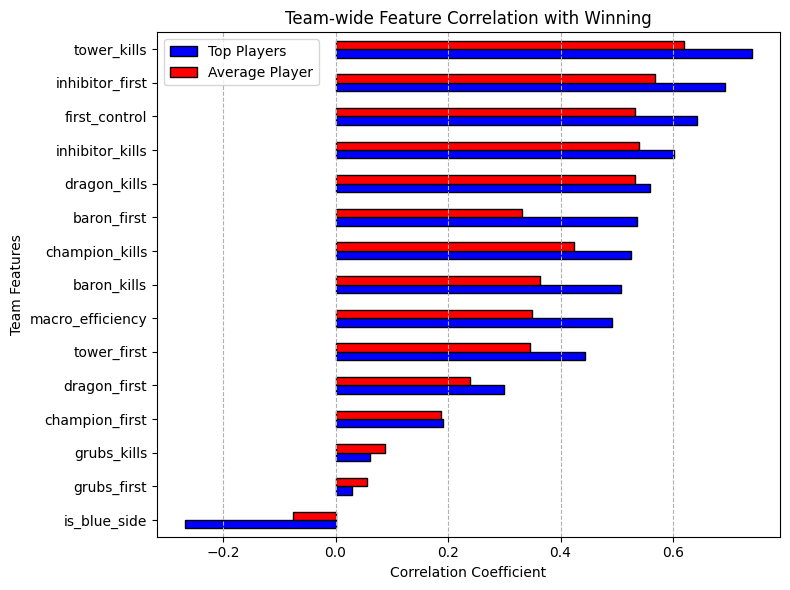

In [23]:
# With us now having of the top players data, find trends/correlations with wins
# Get numeric team data, find trends/correlations with team features and wins. Create data visualization
top_teams_df = pd.read_sql("SELECT * from teams WHERE rank_group = 'Top'", conn)
av_teams_df = pd.read_sql("SELECT * from teams WHERE rank_group = 'Average'", conn)

top_teams_df['is_blue_side'] = (top_teams_df['team_id'] == 100).astype(int)
av_teams_df['is_blue_side'] = (av_teams_df['team_id'] == 100).astype(int)

top_teams = top_teams_df.select_dtypes(include='number').corr()['win'].drop(['win', 'team_id'])
av_teams = av_teams_df.select_dtypes(include='number').corr()['win'].drop(['win', 'team_id'])

team_comparison = pd.DataFrame({'Top Players': top_teams, 'Average Player': av_teams}).sort_values(by='Top Players', ascending=True)
team_comparison.plot(kind='barh', figsize=(8,6), color=['blue', 'red'], edgecolor='black')

plt.title(f'Team-wide Feature Correlation with Winning')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--')
plt.ylabel('Team Features')
plt.tight_layout()
plt.show()

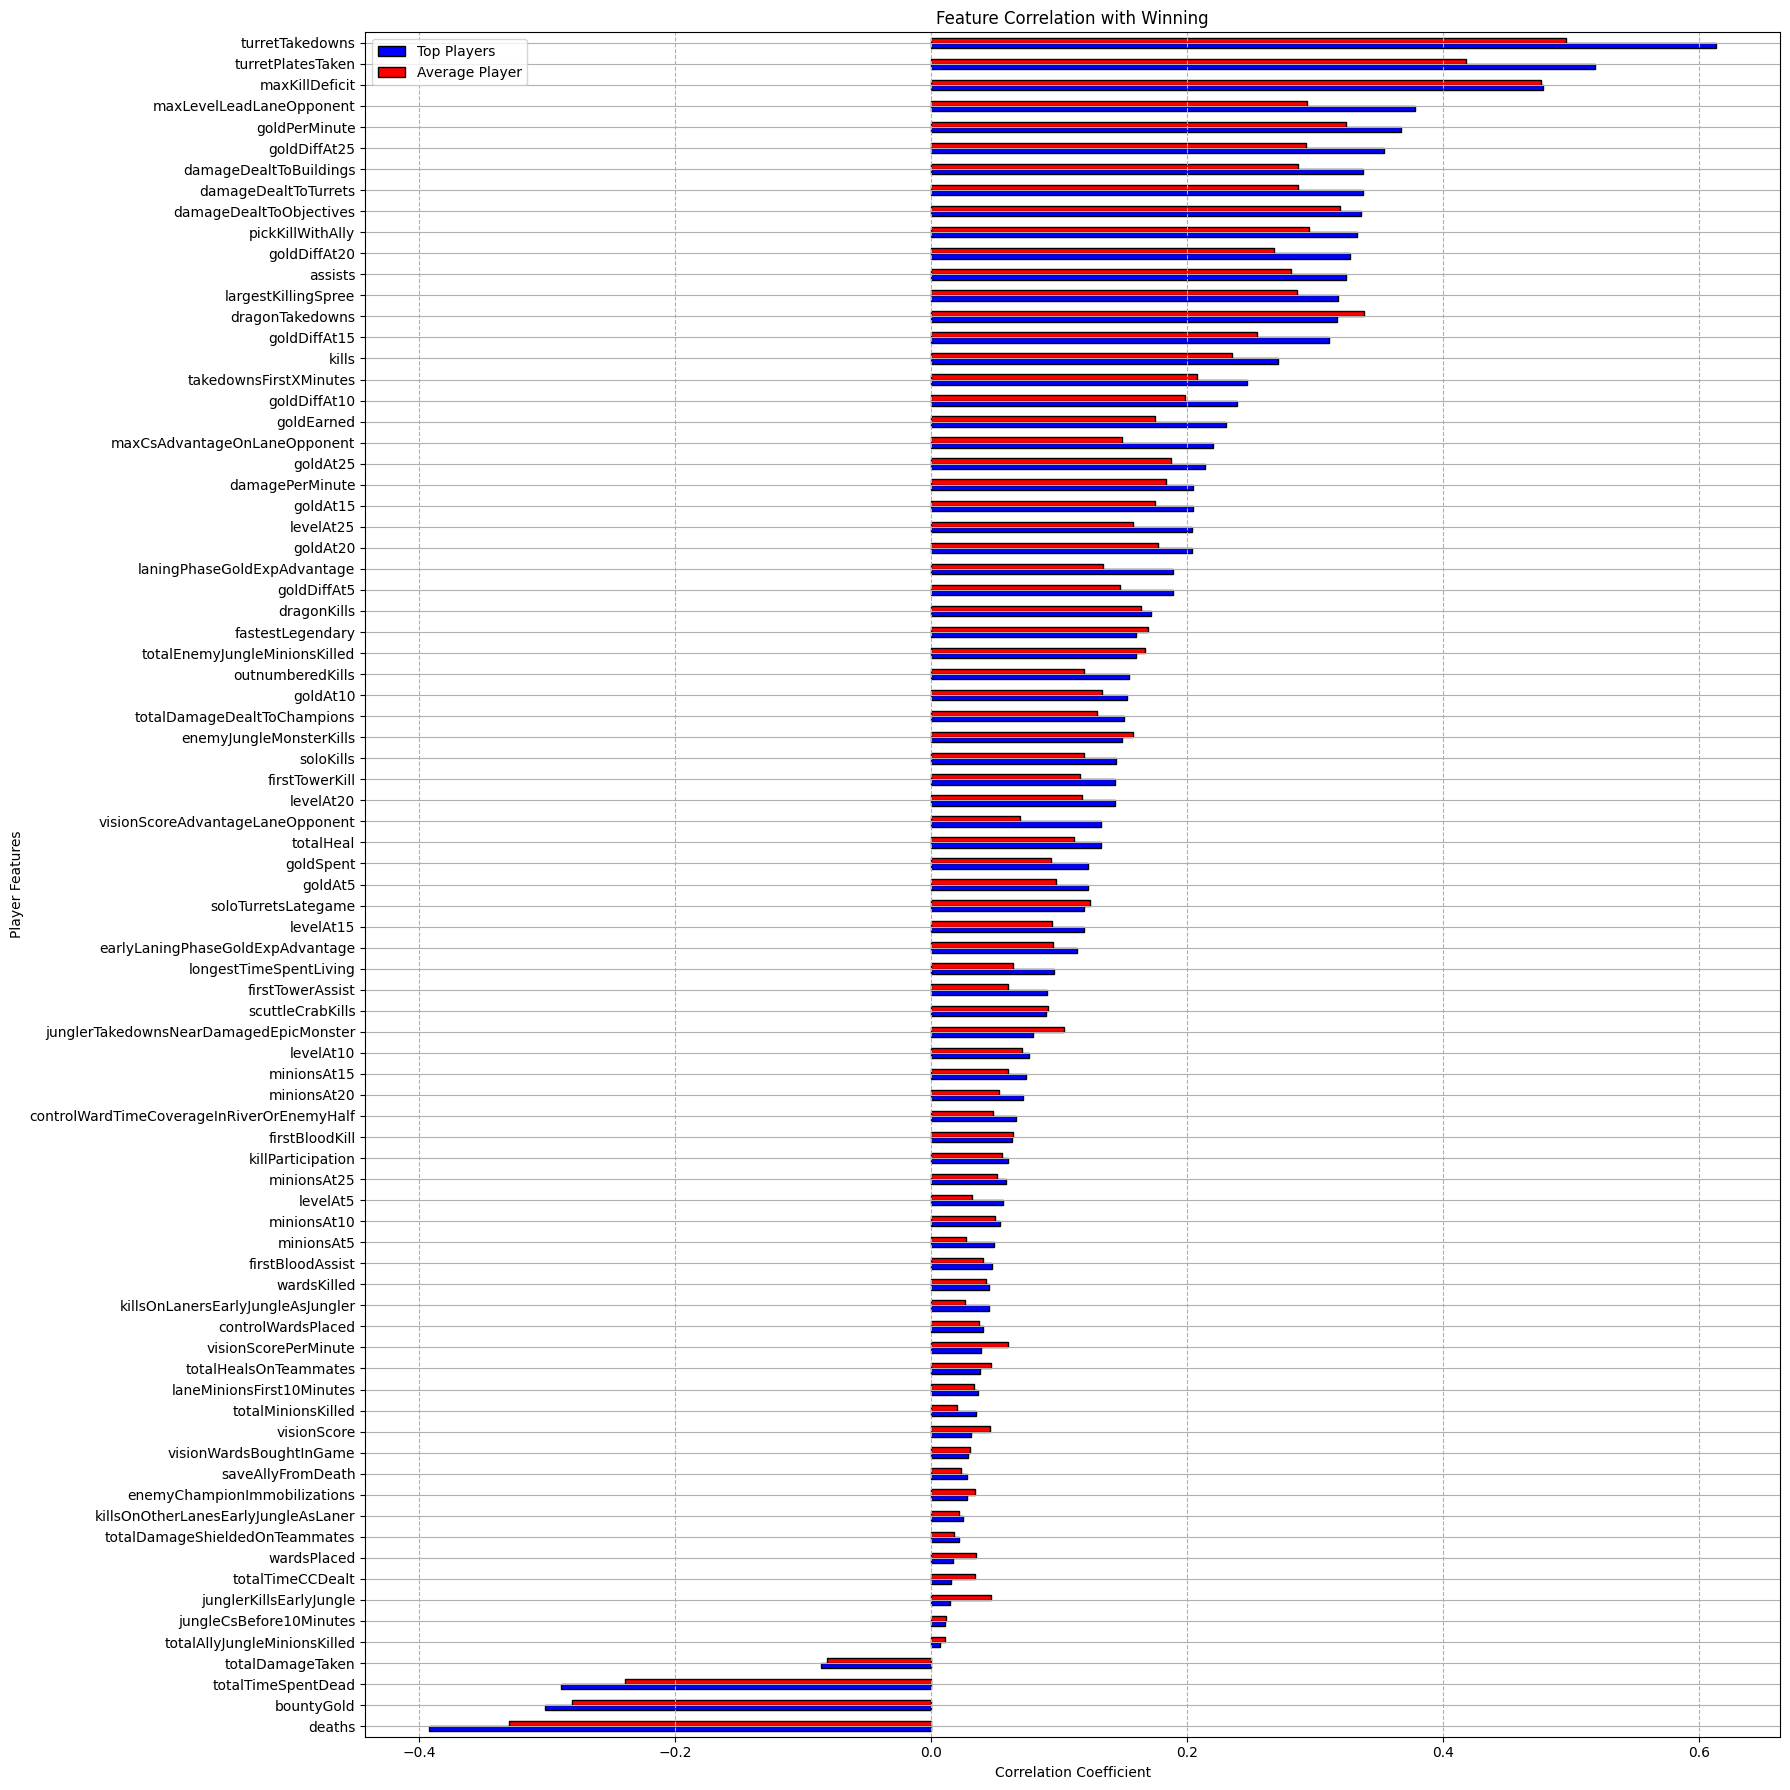

In [24]:
# Get numeric player data, find trends/correlations with player oriented features and wins. Create data visualization
# Top players
top_players_df = pd.read_sql("SELECT * from participants WHERE rank_group = 'Top'", conn)
av_players_df = pd.read_sql("SELECT * from participants WHERE rank_group = 'Average'", conn)

drop_ids = ['win', 'item0', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'summOne', 'summTwo', 'championId', 'team_id', 'gameEndedInSurrender', 'gameEndedInEarlySurrender', 'takedownsFirst25Minutes']

top_players_df['win'] = top_players_df['win'].astype(int)
top_numeric_corr = top_players_df.select_dtypes(include='number').corr()['win'].drop(drop_ids)

av_players_df['win'] = av_players_df['win'].astype(int)
av_numeric_corr = av_players_df.select_dtypes(include='number').corr()['win'].drop(drop_ids)

corr_matrix= pd.DataFrame({'Top Players': top_numeric_corr, 'Average Player': av_numeric_corr})

significant_corrs = corr_matrix.sort_values(by='Top Players', ascending=True)

significant_corrs.plot(kind='barh', figsize=(18, 18), color=['blue', 'red'], edgecolor='black')
plt.title(f'Feature Correlation with Winning')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--')
plt.ylabel('Player Features')
plt.grid(True)
plt.tight_layout()
plt.show()

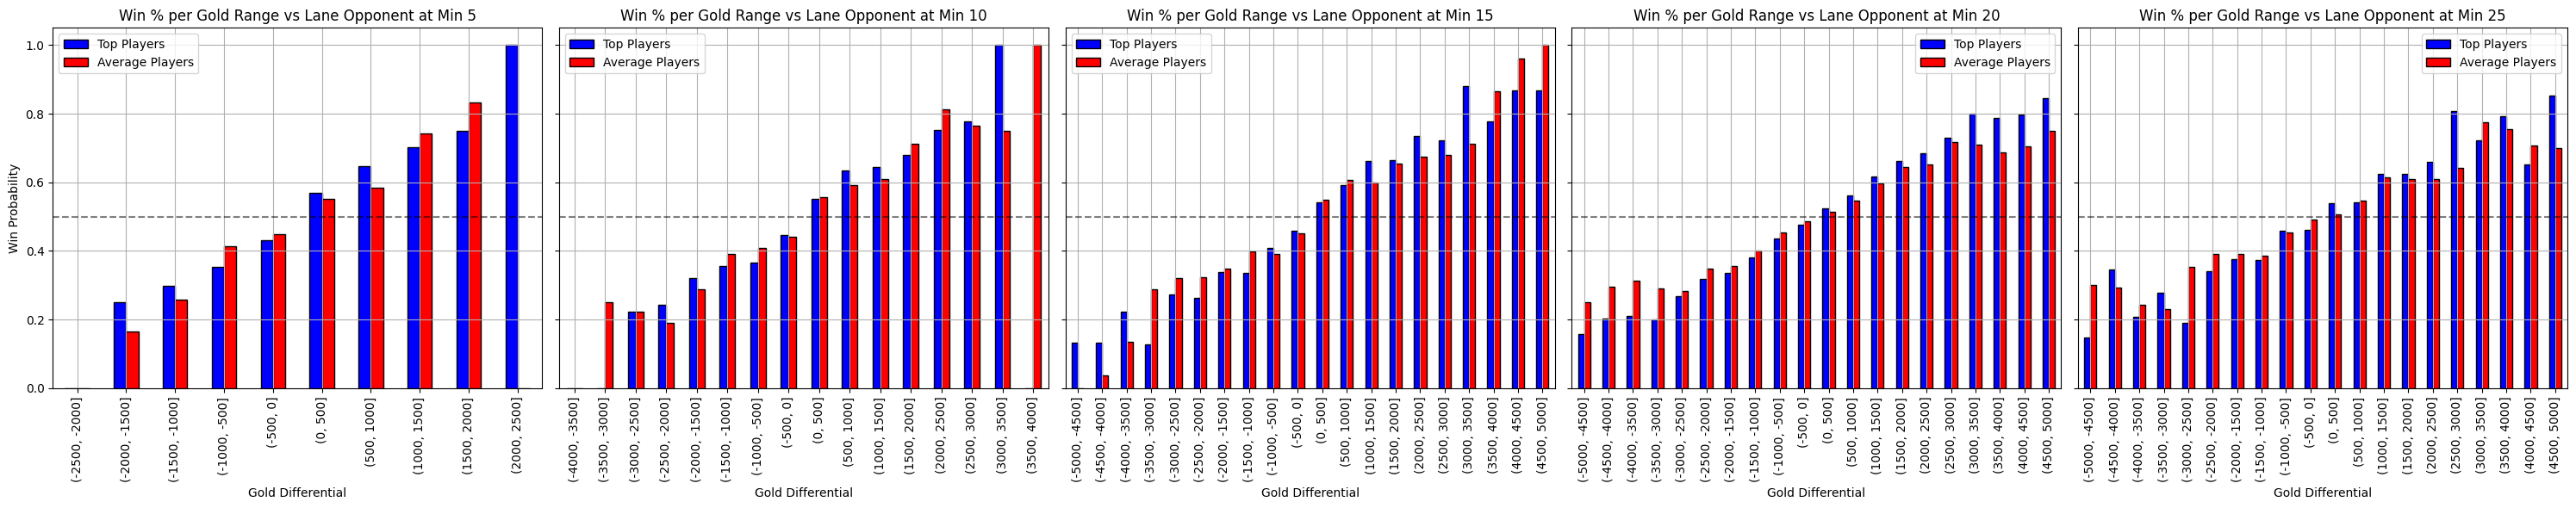

In [22]:
# Use snapshots of total gold leads at timestamps to find if there is a correlation between gold leads at and wins as time goes on
# Find what point in the game gold leads matter most. Create data visualization
fig, axes = plt.subplots(1, len(intervals), figsize=(30, 6), sharey=True)
if(len(intervals) == 1): axes = [axes]

for index, minute in enumerate(intervals):
    ax = axes[index]

    top_players_df[f'goldRangeAt{minute}'] = pd.cut(top_players_df[f'goldDiffAt{minute}'], bins=range(-5000, 5500, 500), right=True)
    top_win_analysis = top_players_df.groupby(f'goldRangeAt{minute}')['win'].mean()

    av_players_df[f'goldRangeAt{minute}'] = pd.cut(av_players_df[f'goldDiffAt{minute}'], bins=range(-5000, 5500, 500), right=True)
    av_win_analysis = av_players_df.groupby(f'goldRangeAt{minute}')['win'].mean()

    win_analysis = pd.DataFrame({'Top Players': top_win_analysis, "Average Players": av_win_analysis})

    win_analysis.plot(kind='bar', ax=ax, edgecolor='black', color=['blue', 'red'])
    ax.set_title(f'Win % per Gold Range vs Lane Opponent at Min {minute}')
    ax.set_xlabel('Gold Differential')
    ax.set_ylabel('Win Probability')
    ax.axhline(.5, color='black', linestyle='--', alpha=.5)
    ax.grid(True)

plt.tight_layout()
plt.show()

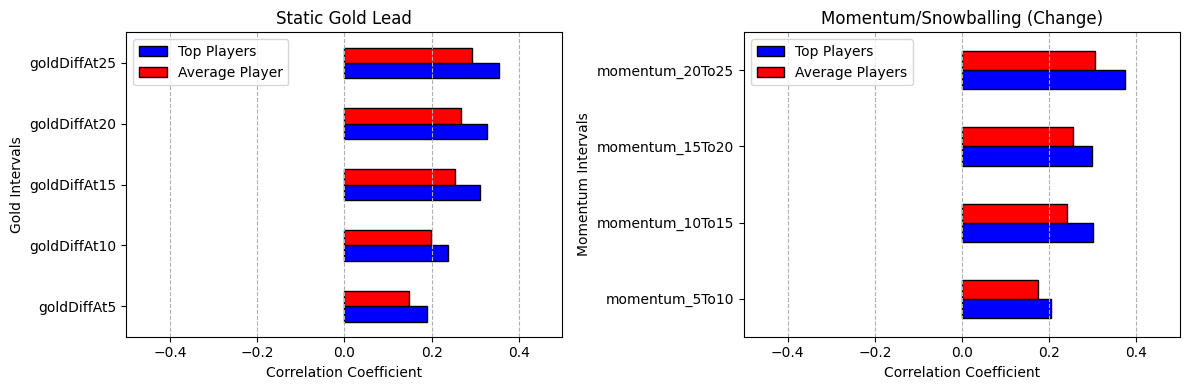

In [21]:
# Create dynamic columns to measure the momentum of a game within specific timeframes, and if leads snowball into wins
# Find what point in the game gold leads matter most. Create data visualization
differential_cols = [f'goldDiffAt{interval}' for interval in intervals]
momentum_cols = []

for df in [top_players_df, av_players_df]:
    for i in range(len(intervals) - 1):
        start = intervals[i]
        end = intervals[i+1]
        col = f'momentum_{start}To{end}'

        if col not in momentum_cols:
            momentum_cols.append(col)
        df[col] = df[f'goldDiffAt{end}'] - df[f'goldDiffAt{start}']

fig, axes = plt.subplots(1, 2, figsize=(12,4))
x_limit = [-.5, .5]

top_static = top_players_df[differential_cols + ['win']].corr()['win'].drop('win')
av_static = av_players_df[differential_cols + ['win']].corr()['win'].drop('win')

static_comparison = pd.DataFrame({'Top Players': top_static, 'Average Player': av_static})
static_comparison.plot(kind='barh', ax=axes[0], color=['blue', 'red'], edgecolor='black')
axes[0].set_title(f'Static Gold Lead')
axes[0].set_xlabel(f'Correlation Coefficient')
axes[0].set_ylabel(f'Gold Intervals')
axes[0].set_xlim(x_limit)
axes[0].grid(axis='x', linestyle='--')

top_dynamic = top_players_df[momentum_cols + ['win']].corr()['win'].drop('win')
av_dynamic = av_players_df[momentum_cols + ['win']].corr()['win'].drop('win')
dynamic_comparison = pd.DataFrame({'Top Players': top_dynamic, 'Average Players': av_dynamic})
dynamic_comparison.plot(kind='barh', ax=axes[1], color=['blue', 'red'], edgecolor='black')
axes[1].set_title(f'Momentum/Snowballing (Change)')
axes[1].set_xlabel(f'Correlation Coefficient')
axes[1].set_xlim(x_limit)
axes[1].set_ylabel(f'Momentum Intervals')
axes[1].grid(axis='x', linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
conn.close()